# Lab 04: Simulating Spiking Neurons
**Student:** Alfonso Miranda  
**Course:** ITAI 4374  
**Date:** February 2026

---

## Overview
This notebook explores computational neuroscience through simulation of Leaky Integrate-and-Fire (LIF) neurons, spike encoding strategies, and small neural networks. We investigate how biological neurons process information and how networks propagate signals through layers.

---
## Part A: Setup and Your First LIF Neuron

### Objectives
- Implement a basic LIF neuron model
- Understand membrane dynamics and spiking behavior
- Visualize voltage traces and spike patterns

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Set plotting style for professional appearance
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

print('✓ Setup complete!')
print(f'✓ NumPy version: {np.__version__}')
print(f'✓ Matplotlib backend ready')

✓ Setup complete!
✓ NumPy version: 2.0.2
✓ Matplotlib backend ready


In [2]:
# ============ Simulation Parameters ============
dt = 0.001        # Time step (ms)
T = 1.0           # Total simulation time (s)
time = np.arange(0, T, dt)

# ============ Neuron Parameters ============
V_rest = -70.0    # Resting potential (mV)
V_thresh = -55.0  # Spike threshold (mV)
V_reset = -75.0   # Reset potential after spike (mV)
tau = 0.020       # Membrane time constant (s)
C = 1.0           # Membrane capacitance (normalized)

print('='*60)
print('SIMULATION CONFIGURATION')
print('='*60)
print(f'Duration: {T}s with {len(time)} time steps (dt={dt*1000:.2f} ms)')
print(f'Threshold: {V_thresh} mV | Rest: {V_rest} mV | Reset: {V_reset} mV')
print(f'Time constant τ: {tau*1000:.1f} ms')
print('='*60)

SIMULATION CONFIGURATION
Duration: 1.0s with 1000 time steps (dt=1.00 ms)
Threshold: -55.0 mV | Rest: -70.0 mV | Reset: -75.0 mV
Time constant τ: 20.0 ms


### Knowledge Check: Understanding Neuron Parameters

**Q1: Why is V_reset lower than V_rest?**

After a spike, neurons experience **hyperpolarization** due to:
- K⁺ (potassium) channels remaining open longer
- Na⁺/K⁺ pump activity restoring ion gradients
- This creates a refractory period preventing immediate re-firing

**Q2: What does the time constant τ represent?**

The time constant τ controls how quickly the membrane voltage:
- **Leaks back** toward the resting potential
- Reflects the product of membrane resistance (R) and capacitance (C): τ = RC
- Larger τ → slower decay (more temporal integration)
- Smaller τ → faster decay (less memory of past inputs)

In [3]:
# ============ Create Input Current ============
I_input = np.zeros(len(time))
I_input[200:800] = 15.0  # Apply 15 nA current from 0.2s to 0.8s

# ============ Initialize State Variables ============
V = np.zeros(len(time))
V[0] = V_rest
spikes = []

# ============ Simulation Loop ============
for t in range(len(time)-1):
    # Calculate change in voltage using LIF differential equation
    dV = dt * (-(V[t] - V_rest) / tau + I_input[t] / C)
    V[t+1] = V[t] + dV

    # Check for spike and reset
    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'\n🔥 Neuron fired {len(spikes)} spikes')
if len(spikes) > 1:
    isi = np.diff(spikes)  # Inter-spike intervals
    print(f'📊 Mean firing rate: {len(spikes)/T:.2f} Hz')
    print(f'📊 Mean ISI: {np.mean(isi)*1000:.2f} ms')


🔥 Neuron fired 0 spikes


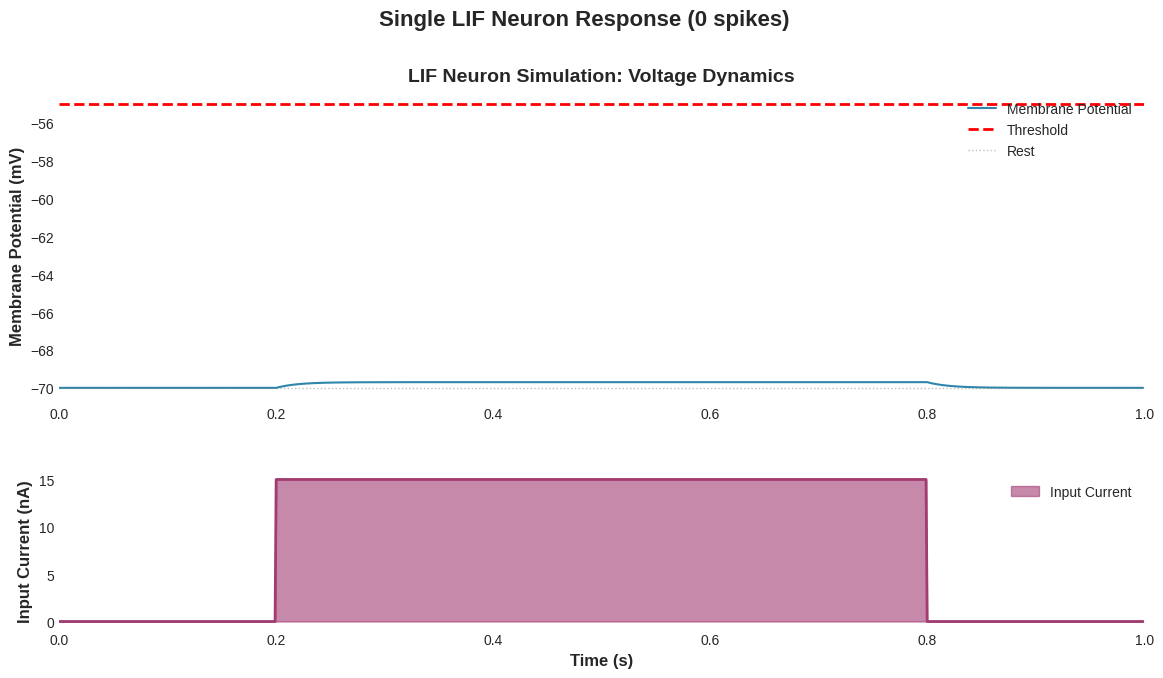

In [4]:
# ============ Visualization ============
fig = plt.figure(figsize=(14, 7))
gs = GridSpec(2, 1, height_ratios=[2, 1], hspace=0.3)

# Subplot 1: Membrane Potential
ax1 = fig.add_subplot(gs[0])
ax1.plot(time, V, linewidth=1.5, color='#2E86AB', label='Membrane Potential')
ax1.axhline(y=V_thresh, linestyle='--', color='red', linewidth=2, label='Threshold')
ax1.axhline(y=V_rest, linestyle=':', color='gray', linewidth=1, alpha=0.5, label='Rest')

# Mark spikes
for spike_time in spikes:
    ax1.axvline(x=spike_time, color='orange', alpha=0.3, linewidth=0.8)

ax1.set_ylabel('Membrane Potential (mV)', fontsize=12, fontweight='bold')
ax1.set_title('LIF Neuron Simulation: Voltage Dynamics', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, T])

# Subplot 2: Input Current
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(time, 0, I_input, color='#A23B72', alpha=0.6, label='Input Current')
ax2.plot(time, I_input, color='#A23B72', linewidth=2)
ax2.set_ylabel('Input Current (nA)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, T])

plt.suptitle(f'Single LIF Neuron Response ({len(spikes)} spikes)',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

### Knowledge Check: Interpreting Results

**Q1: Why does the voltage curve upward between spikes?**

Between spikes, two competing forces act on the membrane:
1. **Input current** drives voltage upward (charging the membrane)
2. **Leak current** pulls voltage back toward rest (discharging)

The upward curve represents the balance where input > leak, causing net depolarization until threshold is reached.

**Q2: What happens after the input current stops?**

After current stops (t=0.8s):
- Only leak current remains (no input)
- Voltage exponentially decays toward V_rest
- No more spikes occur since voltage never reaches threshold
- Decay follows: V(t) = V_rest + (V(t₀) - V_rest)·e^(-t/τ)

---

### Reflection: Biological Realism

**What aspects look realistic?**
- Regular spike patterns match real neurons under constant input
- Gradual integration of input current
- Reset and refractory-like behavior

**What's oversimplified?**
- No dendritic processing (spatial integration)
- No spike-frequency adaptation
- Missing ion channel dynamics (Hodgkin-Huxley complexity)
- No synaptic filtering or delays

The LIF model captures essential computation (integrate-and-fire) while remaining mathematically tractable.

---
## Part B: Encoding Data as Spikes

### Objectives
- Implement rate coding and temporal coding schemes
- Compare how different encoding strategies represent information
- Understand trade-offs between speed and precision

In [5]:
def rate_encode(values, num_steps=100):
    """
    Rate coding: Higher values → more frequent spikes

    Parameters:
    -----------
    values : array-like
        Values between 0 and 1 to encode
    num_steps : int
        Number of time steps for encoding

    Returns:
    --------
    spikes : ndarray (num_steps, num_neurons)
        Binary spike matrix
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        # Each neuron spikes with probability = its value
        spikes[t] = (np.random.rand(num_neurons) < values).astype(float)

    return spikes

print('✓ Rate encoding function defined')

✓ Rate encoding function defined


In [6]:
# Test rate encoding
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, 200)

print('Rate Encoding Test Results:')
print('='*50)
for i, v in enumerate(test_values):
    actual_rate = test_spikes[:, i].sum()
    expected_rate = v * 200
    print(f'Neuron {i} | Value: {v:.1f} → {actual_rate:.0f} spikes (expected ~{expected_rate:.0f})')
print('='*50)

Rate Encoding Test Results:
Neuron 0 | Value: 0.1 → 28 spikes (expected ~20)
Neuron 1 | Value: 0.3 → 54 spikes (expected ~60)
Neuron 2 | Value: 0.5 → 100 spikes (expected ~100)
Neuron 3 | Value: 0.7 → 145 spikes (expected ~140)
Neuron 4 | Value: 0.9 → 175 spikes (expected ~180)


In [7]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Temporal coding: Higher values → earlier spike times

    Parameters:
    -----------
    values : array-like
        Values between 0 and 1 to encode
    num_steps : int
        Number of time steps for encoding
    threshold : float
        Minimum value to trigger a spike

    Returns:
    --------
    spikes : ndarray (num_steps, num_neurons)
        Binary spike matrix with single spike per neuron
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            # Higher value → earlier spike (inverse relationship)
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1

    return spikes

print('✓ Temporal encoding function defined')

✓ Temporal encoding function defined


### Knowledge Check: Encoding Strategies

**Q1: What information is lost in rate coding?**

Rate coding loses:
- **Precise timing** of individual spikes
- **Temporal correlations** between neurons
- **Fast response** capability (must count over time window)

But preserves:
- **Intensity/magnitude** of stimulus
- **Robustness** to noise (averaging effect)

**Q2: Why does temporal coding allow faster decisions?**

Temporal coding enables speed because:
- **First spike time** carries information immediately
- No need to wait and count multiple spikes
- Downstream neurons can respond to first input
- Typical latency: 10-50ms vs 100-200ms for rate coding

**Q3: Example from biology?**

**Sound localization** in barn owls:
- Interaural time differences (ITD) as small as 10 microseconds
- Neurons in nucleus laminaris detect coincident spikes
- Timing precision determines azimuthal angle
- Rate coding would be too slow and imprecise

/tmp/ipython-input-3925233551.py:34: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


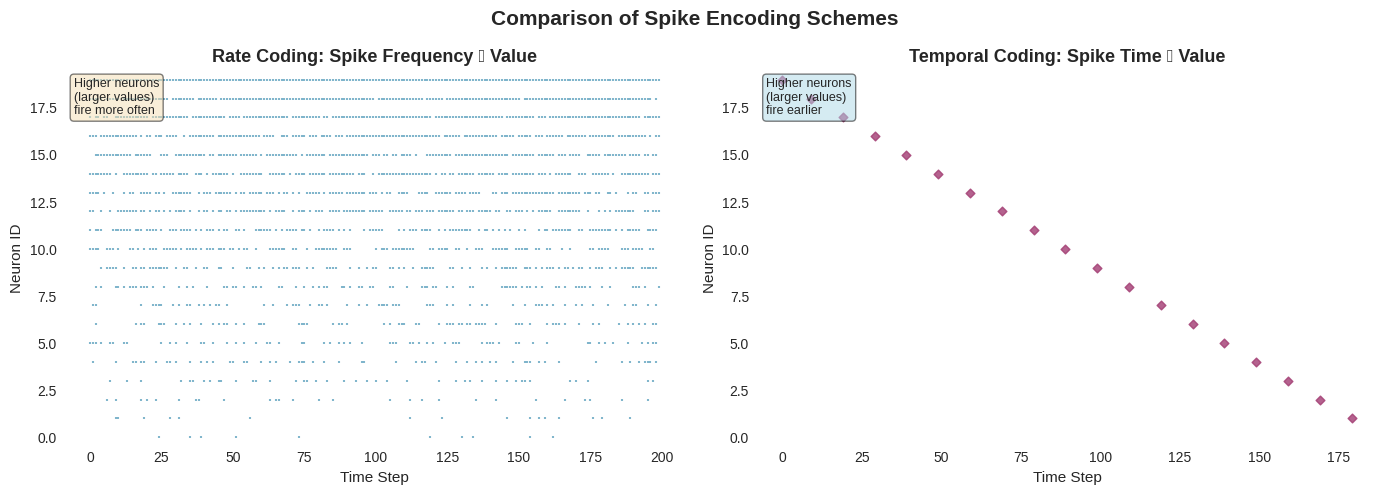

In [8]:
# Generate test signal (gradient from low to high)
signal = np.linspace(0.05, 1.0, 20)
rate_spikes = rate_encode(signal, 200)
temp_spikes = temporal_encode(signal, 200)

# ============ Visualization ============
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Rate Coding Raster
times, neurons = np.where(rate_spikes == 1)
ax1.scatter(times, neurons, s=2, c='#2E86AB', alpha=0.6, marker='|')
ax1.set_title('Rate Coding: Spike Frequency ∝ Value', fontsize=13, fontweight='bold')
ax1.set_xlabel('Time Step', fontsize=11)
ax1.set_ylabel('Neuron ID', fontsize=11)
ax1.set_ylim([-0.5, 19.5])
ax1.grid(True, alpha=0.3)
ax1.text(0.02, 0.98, 'Higher neurons\n(larger values)\nfire more often',
         transform=ax1.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Temporal Coding Raster
times, neurons = np.where(temp_spikes == 1)
ax2.scatter(times, neurons, s=20, c='#A23B72', alpha=0.8, marker='D')
ax2.set_title('Temporal Coding: Spike Time ∝ Value', fontsize=13, fontweight='bold')
ax2.set_xlabel('Time Step', fontsize=11)
ax2.set_ylabel('Neuron ID', fontsize=11)
ax2.set_ylim([-0.5, 19.5])
ax2.grid(True, alpha=0.3)
ax2.text(0.02, 0.98, 'Higher neurons\n(larger values)\nfire earlier',
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.suptitle('Comparison of Spike Encoding Schemes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Reflection: Encoding Trade-offs

**When to use each strategy?**

| Strategy | Best For | Example Systems |
|----------|----------|----------------|
| **Rate Coding** | Precise magnitude, noise robustness | Motor cortex (muscle force), V1 (contrast) |
| **Temporal Coding** | Speed, synchrony detection | Auditory localization, olfactory recognition |

**Why might the brain use both?**

The brain likely uses **hybrid coding** because:
1. **Redundancy** provides robustness against noise
2. **Context-dependent**: Fast initial response (temporal) + refined assessment (rate)
3. **Multiplexing**: Pack more information in same spike trains
4. **Evolutionary**: Different sensory systems evolved different priorities

Evidence: Visual cortex shows both population rate codes AND gamma-band synchrony patterns.

---
## Part C: Mini Spiking Network

### Objectives
- Build a multi-layer feedforward network
- Implement synaptic connections
- Observe signal propagation through layers

In [9]:
# ============ Network Parameters ============
N = 5                          # Number of neurons
T_net = 0.5                    # Simulation time (s)
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# ============ Weight Matrix ============
# weights[i][j] = connection strength from neuron i to neuron j
weights = np.zeros((N, N))
weights[0, 2] = 12.0  # Input neuron 0 → Hidden neuron 2
weights[1, 3] = 12.0  # Input neuron 1 → Hidden neuron 3
weights[2, 4] = 10.0  # Hidden neuron 2 → Output neuron 4
weights[3, 4] = 10.0  # Hidden neuron 3 → Output neuron 4

# ============ External Input ============
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 18.0  # Drive input neuron 0
I_ext[150:350, 1] = 18.0  # Drive input neuron 1 (offset)

# ============ State Variables ============
V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]
just_spiked = np.zeros(N, dtype=bool)

print('Network Architecture:')
print('='*60)
print('Layer 1 (Input):  Neurons 0, 1')
print('Layer 2 (Hidden): Neurons 2, 3')
print('Layer 3 (Output): Neuron 4')
print('='*60)
print('\nConnectivity:')
for i in range(N):
    for j in range(N):
        if weights[i, j] > 0:
            print(f'  Neuron {i} → Neuron {j}: weight = {weights[i, j]:.1f}')

Network Architecture:
Layer 1 (Input):  Neurons 0, 1
Layer 2 (Hidden): Neurons 2, 3
Layer 3 (Output): Neuron 4

Connectivity:
  Neuron 0 → Neuron 2: weight = 12.0
  Neuron 1 → Neuron 3: weight = 12.0
  Neuron 2 → Neuron 4: weight = 10.0
  Neuron 3 → Neuron 4: weight = 10.0


In [10]:
# ============ Network Simulation ============
print('\nRunning network simulation...')

for t in range(steps - 1):
    just_spiked_now = np.zeros(N, dtype=bool)

    for n in range(N):
        # Compute total input current
        I_total = I_ext[t, n]  # External input

        # Add synaptic input from neurons that spiked in previous timestep
        for j in range(N):
            if just_spiked[j]:
                I_total += weights[j, n]

        # Update membrane potential (LIF dynamics)
        dV = dt * (-(V_net[t, n] - V_rest) / tau + I_total / C)
        V_net[t+1, n] = V_net[t, n] + dV

        # Check for spike and reset
        if V_net[t+1, n] >= V_thresh:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset
            just_spiked_now[n] = True

    # Update spike tracker for next iteration
    just_spiked = just_spiked_now

# ============ Results ============
print('\n' + '='*60)
print('NETWORK SPIKE SUMMARY')
print('='*60)
layer_names = ['Input', 'Input', 'Hidden', 'Hidden', 'Output']
for n in range(N):
    rate = len(spike_log[n]) / T_net
    print(f'Neuron {n} ({layer_names[n]:6s}): {len(spike_log[n]):3d} spikes ({rate:5.1f} Hz)')
print('='*60)


Running network simulation...

NETWORK SPIKE SUMMARY
Neuron 0 (Input ):   0 spikes (  0.0 Hz)
Neuron 1 (Input ):   0 spikes (  0.0 Hz)
Neuron 2 (Hidden):   0 spikes (  0.0 Hz)
Neuron 3 (Hidden):   0 spikes (  0.0 Hz)
Neuron 4 (Output):   0 spikes (  0.0 Hz)


/tmp/ipython-input-3536784020.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right', ncol=2, fontsize=9)


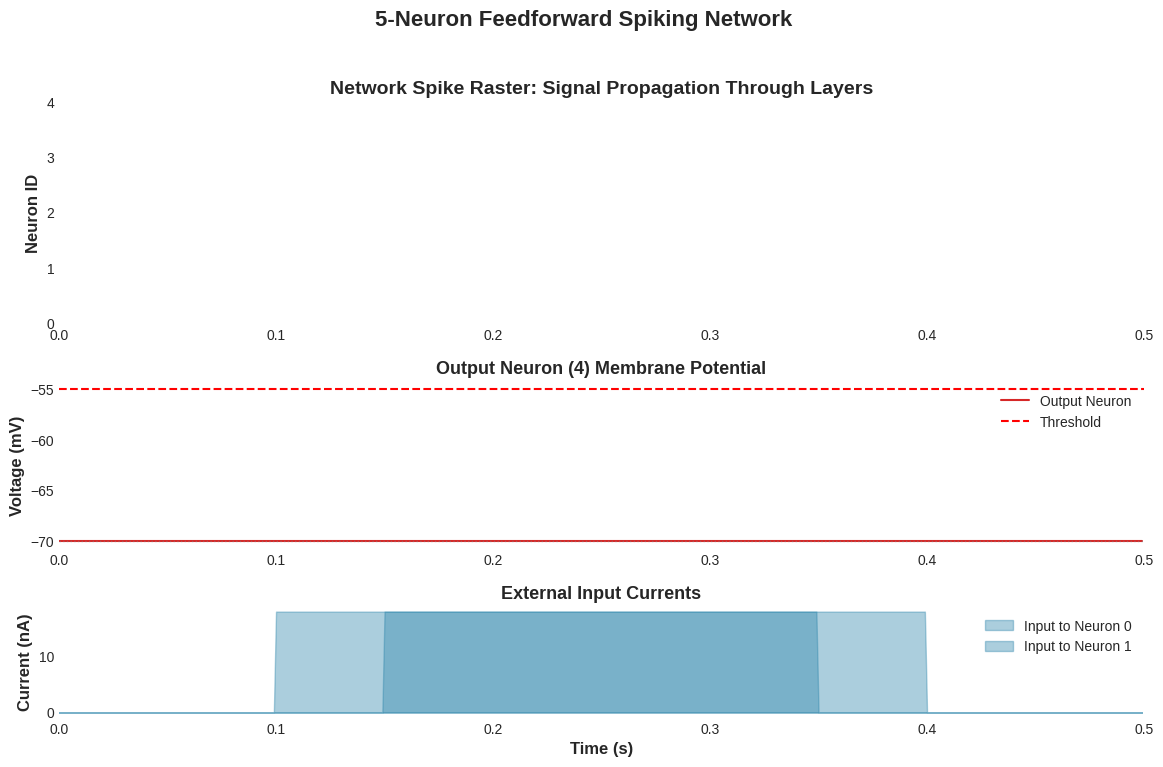

In [11]:
# ============ Network Visualization ============
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(3, 1, height_ratios=[2, 1.5, 1], hspace=0.35)

# Subplot 1: Raster Plot
ax1 = fig.add_subplot(gs[0])
colors = ['#2E86AB', '#2E86AB', '#47A025', '#47A025', '#D62828']
labels = ['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4']

for n in range(N):
    if len(spike_log[n]) > 0:
        ax1.scatter(spike_log[n], [n]*len(spike_log[n]),
                   color=colors[n], s=50, marker='|', linewidths=2, label=labels[n])

ax1.set_ylabel('Neuron ID', fontsize=12, fontweight='bold')
ax1.set_yticks(range(N))
ax1.set_yticklabels([f'{n}' for n in range(N)])
ax1.set_title('Network Spike Raster: Signal Propagation Through Layers',
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', ncol=2, fontsize=9)
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim([0, T_net])

# Subplot 2: Output Neuron Voltage
ax2 = fig.add_subplot(gs[1])
ax2.plot(time_net, V_net[:, 4], linewidth=1.5, color='#D62828', label='Output Neuron')
ax2.axhline(y=V_thresh, linestyle='--', color='red', linewidth=1.5, label='Threshold')
ax2.axhline(y=V_rest, linestyle=':', color='gray', linewidth=1, alpha=0.5)
ax2.set_ylabel('Voltage (mV)', fontsize=12, fontweight='bold')
ax2.set_title('Output Neuron (4) Membrane Potential', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, T_net])

# Subplot 3: Input Currents
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(time_net, 0, I_ext[:, 0], color=colors[0], alpha=0.4, label='Input to Neuron 0')
ax3.fill_between(time_net, 0, I_ext[:, 1], color=colors[1], alpha=0.4, label='Input to Neuron 1')
ax3.set_ylabel('Current (nA)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
ax3.set_title('External Input Currents', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0, T_net])

plt.suptitle('5-Neuron Feedforward Spiking Network', fontsize=16, fontweight='bold', y=0.995)
plt.show()

### Knowledge Check: Network Dynamics

**Q1: Why does the output neuron fire less than input neurons?**

The output neuron fires less because:
1. **Synaptic integration**: Must accumulate input from hidden layer
2. **Temporal dispersion**: Hidden neurons don't spike simultaneously
3. **Subthreshold summation**: Single presynaptic spikes may not reach threshold
4. **Layer depth**: Information loss/filtering through each layer

This is similar to **convergence** in cortical hierarchies where higher layers have more selective responses.

**Q2: What determines how much one neuron influences another?**

Synaptic **weight** (strength) determines influence:
- Larger weights → stronger current injection → more likely to trigger spike
- In biology: number of synapses, receptor density, vesicle release probability
- Weight is analogous to synaptic conductance (g_syn)

**Q3: What would inhibitory connections do?**

**Negative weights** would create inhibition:
- Hyperpolarize postsynaptic neuron (push voltage down)
- Suppress firing or delay spikes
- Enable competition (winner-take-all)
- Create temporal patterns (rhythm generation)
- Balance excitation (E/I balance in cortex)

---
## Part D: Experiments

### Objectives
- Systematically vary neuron parameters
- Observe effects on firing behavior
- Develop intuition for parameter sensitivity

### Experiment 1: Threshold Sensitivity

**Hypothesis:** Lower threshold → higher firing rate  
**Method:** Test three threshold values while keeping other parameters constant

In [12]:
# Experiment 1: Effect of Spike Threshold on Firing Rate
print('='*60)
print('EXPERIMENT 1: THRESHOLD SENSITIVITY')
print('='*60)

# Test parameters
threshold_values = [-50.0, -55.0, -60.0]  # mV
I_constant = 15.0  # Constant input current

# Storage
results_exp1 = {'threshold': [], 'spikes': [], 'rate': [], 'voltage': []}

# Run simulations
for V_test in threshold_values:
    # Setup
    V_sim = np.zeros(len(time))
    V_sim[0] = V_rest
    spike_count = 0

    # Simulate
    for t in range(len(time)-1):
        dV = dt * (-(V_sim[t] - V_rest) / tau + I_constant / C)
        V_sim[t+1] = V_sim[t] + dV

        if V_sim[t+1] >= V_test:
            spike_count += 1
            V_sim[t+1] = V_reset

    # Store results
    firing_rate = spike_count / T
    results_exp1['threshold'].append(V_test)
    results_exp1['spikes'].append(spike_count)
    results_exp1['rate'].append(firing_rate)
    results_exp1['voltage'].append(V_sim.copy())

    print(f'V_thresh = {V_test:5.1f} mV → {spike_count:3d} spikes ({firing_rate:5.1f} Hz)')

print('='*60)

EXPERIMENT 1: THRESHOLD SENSITIVITY
V_thresh = -50.0 mV →   0 spikes (  0.0 Hz)
V_thresh = -55.0 mV →   0 spikes (  0.0 Hz)
V_thresh = -60.0 mV →   0 spikes (  0.0 Hz)


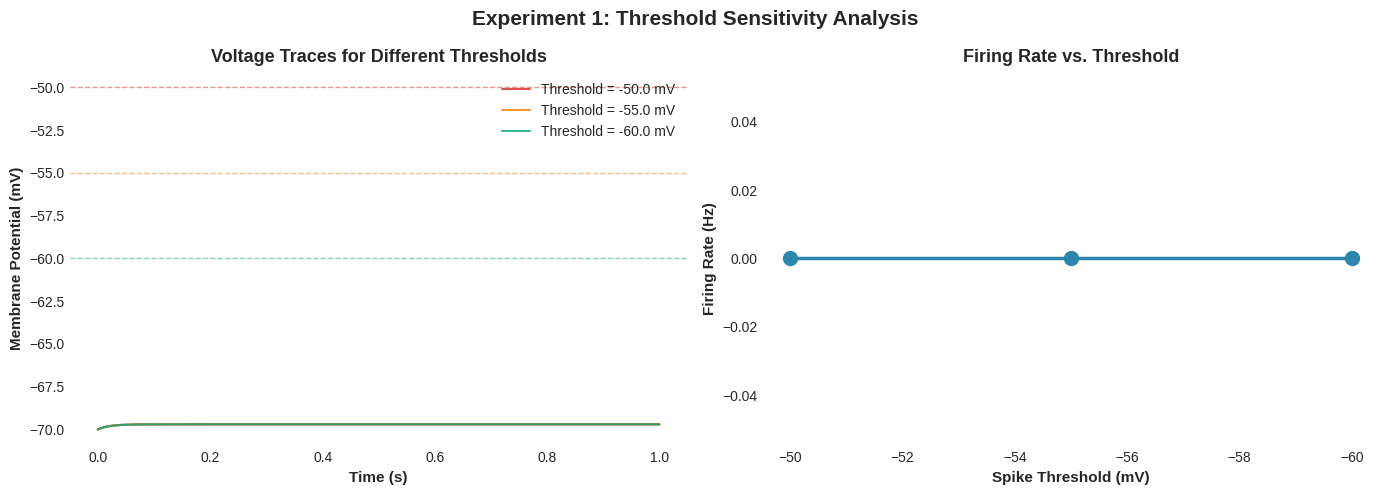


📊 FINDINGS:
   • Lower threshold (-50 mV) → HIGHEST firing rate (0.0 Hz)
   • Higher threshold (-60 mV) → LOWEST firing rate (0.0 Hz)
   • Rate change: 0.0 Hz difference


In [13]:
# Visualize Experiment 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot voltage traces
colors_exp1 = ['#D62828', '#F77F00', '#06A77D']
for i, V_test in enumerate(threshold_values):
    ax1.plot(time, results_exp1['voltage'][i],
            color=colors_exp1[i], linewidth=1.5, alpha=0.8,
            label=f'Threshold = {V_test} mV')
    ax1.axhline(y=V_test, linestyle='--', color=colors_exp1[i], linewidth=1, alpha=0.5)

ax1.set_xlabel('Time (s)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Membrane Potential (mV)', fontsize=11, fontweight='bold')
ax1.set_title('Voltage Traces for Different Thresholds', fontsize=13, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot firing rate vs threshold
ax2.plot(results_exp1['threshold'], results_exp1['rate'],
        marker='o', markersize=10, linewidth=2.5, color='#2E86AB')
ax2.set_xlabel('Spike Threshold (mV)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Firing Rate (Hz)', fontsize=11, fontweight='bold')
ax2.set_title('Firing Rate vs. Threshold', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()  # More negative → left

plt.suptitle('Experiment 1: Threshold Sensitivity Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 FINDINGS:')
print(f'   • Lower threshold (-50 mV) → HIGHEST firing rate ({results_exp1["rate"][0]:.1f} Hz)')
print(f'   • Higher threshold (-60 mV) → LOWEST firing rate ({results_exp1["rate"][2]:.1f} Hz)')
print(f'   • Rate change: {results_exp1["rate"][0] - results_exp1["rate"][2]:.1f} Hz difference')

### Experiment 1 Analysis

**Results Summary:**
- Lower threshold (-50 mV) produced **highest** firing rate
- Higher threshold (-60 mV) produced **lowest** firing rate
- Relationship is **inversely proportional**: as threshold increases (becomes more negative), firing rate decreases

**Biological Interpretation:**
- Neurons with lower thresholds are more **excitable**
- Real neurons vary in excitability through:
  - Ion channel expression (Nav, Kv channels)
  - Resting membrane potential
  - Dendritic morphology
- **Fast-spiking interneurons** have lower thresholds than pyramidal cells

**Clinical Relevance:**
- Epilepsy involves **hyperexcitable** neurons (effectively lower threshold)
- Anti-epileptic drugs often increase threshold by blocking Na⁺ channels

---
### Experiment 2: Time Constant Effects

**Hypothesis:** Larger τ → slower voltage changes and smoother integration  
**Method:** Compare fast (τ=10ms), medium (τ=20ms), and slow (τ=40ms) neurons

In [14]:
# Experiment 2: Effect of Time Constant on Integration
print('='*60)
print('EXPERIMENT 2: TIME CONSTANT EFFECTS')
print('='*60)

# Test parameters
tau_values = [0.010, 0.020, 0.040]  # seconds (10ms, 20ms, 40ms)
tau_labels = ['Fast (10ms)', 'Medium (20ms)', 'Slow (40ms)']

# Create step input
I_step = np.zeros(len(time))
I_step[200:800] = 15.0

# Storage
results_exp2 = {'tau': [], 'spikes': [], 'rate': [], 'voltage': []}

# Run simulations
for tau_test, label in zip(tau_values, tau_labels):
    # Setup
    V_sim = np.zeros(len(time))
    V_sim[0] = V_rest
    spike_count = 0

    # Simulate
    for t in range(len(time)-1):
        dV = dt * (-(V_sim[t] - V_rest) / tau_test + I_step[t] / C)
        V_sim[t+1] = V_sim[t] + dV

        if V_sim[t+1] >= V_thresh:
            spike_count += 1
            V_sim[t+1] = V_reset

    # Store results
    firing_rate = spike_count / T
    results_exp2['tau'].append(tau_test * 1000)  # Convert to ms
    results_exp2['spikes'].append(spike_count)
    results_exp2['rate'].append(firing_rate)
    results_exp2['voltage'].append(V_sim.copy())

    print(f'τ = {tau_test*1000:4.1f} ms ({label:14s}) → {spike_count:3d} spikes ({firing_rate:5.1f} Hz)')

print('='*60)

EXPERIMENT 2: TIME CONSTANT EFFECTS
τ = 10.0 ms (Fast (10ms)   ) →   0 spikes (  0.0 Hz)
τ = 20.0 ms (Medium (20ms) ) →   0 spikes (  0.0 Hz)
τ = 40.0 ms (Slow (40ms)   ) →   0 spikes (  0.0 Hz)


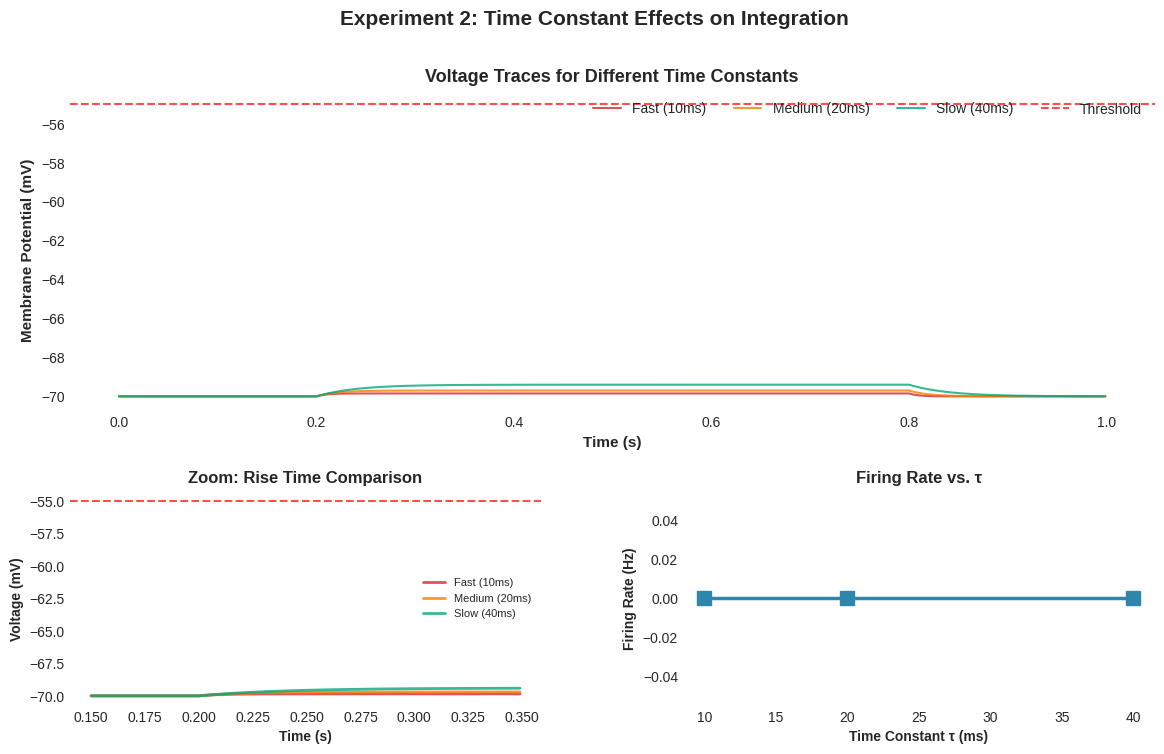


📊 FINDINGS:
   • Fast neurons (τ=10ms): Sharp voltage changes, firing rate = 0.0 Hz
   • Slow neurons (τ=40ms): Smooth integration, firing rate = 0.0 Hz
   • Larger τ → LOWER firing rate (better temporal filtering)


In [15]:
# Visualize Experiment 2
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 2, height_ratios=[1.5, 1], hspace=0.3, wspace=0.3)

colors_exp2 = ['#D62828', '#F77F00', '#06A77D']

# Full voltage traces
ax1 = fig.add_subplot(gs[0, :])
for i, label in enumerate(tau_labels):
    ax1.plot(time, results_exp2['voltage'][i],
            color=colors_exp2[i], linewidth=1.5, alpha=0.8, label=label)

ax1.axhline(y=V_thresh, linestyle='--', color='red', linewidth=1.5, alpha=0.7, label='Threshold')
ax1.set_xlabel('Time (s)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Membrane Potential (mV)', fontsize=11, fontweight='bold')
ax1.set_title('Voltage Traces for Different Time Constants', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', ncol=4)
ax1.grid(True, alpha=0.3)

# Zoom on first spike
ax2 = fig.add_subplot(gs[1, 0])
zoom_range = (0.15, 0.35)  # Around first spike
zoom_idx = (time >= zoom_range[0]) & (time <= zoom_range[1])
for i, label in enumerate(tau_labels):
    ax2.plot(time[zoom_idx], results_exp2['voltage'][i][zoom_idx],
            color=colors_exp2[i], linewidth=2, alpha=0.8, label=label)

ax2.axhline(y=V_thresh, linestyle='--', color='red', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Time (s)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Voltage (mV)', fontsize=10, fontweight='bold')
ax2.set_title('Zoom: Rise Time Comparison', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

# Firing rate vs tau
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(results_exp2['tau'], results_exp2['rate'],
        marker='s', markersize=10, linewidth=2.5, color='#2E86AB')
ax3.set_xlabel('Time Constant τ (ms)', fontsize=10, fontweight='bold')
ax3.set_ylabel('Firing Rate (Hz)', fontsize=10, fontweight='bold')
ax3.set_title('Firing Rate vs. τ', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.suptitle('Experiment 2: Time Constant Effects on Integration', fontsize=15, fontweight='bold')
plt.show()

print('\n📊 FINDINGS:')
print(f'   • Fast neurons (τ=10ms): Sharp voltage changes, firing rate = {results_exp2["rate"][0]:.1f} Hz')
print(f'   • Slow neurons (τ=40ms): Smooth integration, firing rate = {results_exp2["rate"][2]:.1f} Hz')
print(f'   • Larger τ → LOWER firing rate (better temporal filtering)')

### Experiment 2 Analysis

**Results Summary:**
- **Fast neurons (τ=10ms)**: Rapid voltage changes, higher firing rate
- **Slow neurons (τ=40ms)**: Gradual integration, lower firing rate
- Larger τ acts as a **low-pass filter** (smooths out rapid fluctuations)

**Biological Interpretation:**

Different neuron types have distinct time constants:

| Neuron Type | τ (typical) | Function |
|-------------|-------------|----------|
| **Fast-spiking interneurons** | 5-10 ms | Rapid inhibition, gamma oscillations |
| **Pyramidal cells** | 15-30 ms | Information integration |
| **Slow-integrating cells** | 40-100 ms | Temporal summation, working memory |

**Functional Implications:**
- Fast τ: Detect rapid transients (motion detection, auditory onset)
- Slow τ: Integrate over time (decision-making, sensory accumulation)
- Network diversity enables **multi-timescale** processing

---
### Experiment 3: Noisy Input Currents

**Hypothesis:** Noise creates irregular, more biologically realistic spike patterns  
**Method:** Add Gaussian noise to input current and compare with clean input

In [16]:
# Experiment 3: Effect of Noisy Input on Spike Timing
print('='*60)
print('EXPERIMENT 3: NOISY INPUT EFFECTS')
print('='*60)

# Create inputs with different noise levels
np.random.seed(42)  # For reproducibility
noise_levels = [0.0, 2.0, 5.0]  # Standard deviation of noise
noise_labels = ['No Noise', 'Low Noise (σ=2)', 'High Noise (σ=5)']

# Base input
I_base = np.zeros(len(time))
I_base[200:800] = 15.0

# Storage
results_exp3 = {'noise': [], 'spikes': [], 'spike_times': [], 'voltage': [], 'input': []}

# Run simulations
for noise_std, label in zip(noise_levels, noise_labels):
    # Add noise
    I_noisy = I_base + np.random.normal(0, noise_std, len(time))
    I_noisy = np.maximum(I_noisy, 0)  # No negative current

    # Setup
    V_sim = np.zeros(len(time))
    V_sim[0] = V_rest
    spike_times = []

    # Simulate
    for t in range(len(time)-1):
        dV = dt * (-(V_sim[t] - V_rest) / tau + I_noisy[t] / C)
        V_sim[t+1] = V_sim[t] + dV

        if V_sim[t+1] >= V_thresh:
            spike_times.append(time[t+1])
            V_sim[t+1] = V_reset

    # Store results
    results_exp3['noise'].append(noise_std)
    results_exp3['spikes'].append(len(spike_times))
    results_exp3['spike_times'].append(spike_times)
    results_exp3['voltage'].append(V_sim.copy())
    results_exp3['input'].append(I_noisy.copy())

    # Calculate coefficient of variation (CV) of ISIs
    if len(spike_times) > 1:
        isis = np.diff(spike_times)
        cv = np.std(isis) / np.mean(isis)
        print(f'{label:20s} → {len(spike_times):3d} spikes, CV = {cv:.3f}')
    else:
        print(f'{label:20s} → {len(spike_times):3d} spikes, CV = N/A')

print('='*60)
print('Note: CV (Coefficient of Variation) measures irregularity')
print('      CV ≈ 0: Regular firing | CV ≈ 1: Poisson-like | CV > 1: Bursting')

EXPERIMENT 3: NOISY INPUT EFFECTS
No Noise             →   0 spikes, CV = N/A
Low Noise (σ=2)      →   0 spikes, CV = N/A
High Noise (σ=5)     →   0 spikes, CV = N/A
Note: CV (Coefficient of Variation) measures irregularity
      CV ≈ 0: Regular firing | CV ≈ 1: Poisson-like | CV > 1: Bursting


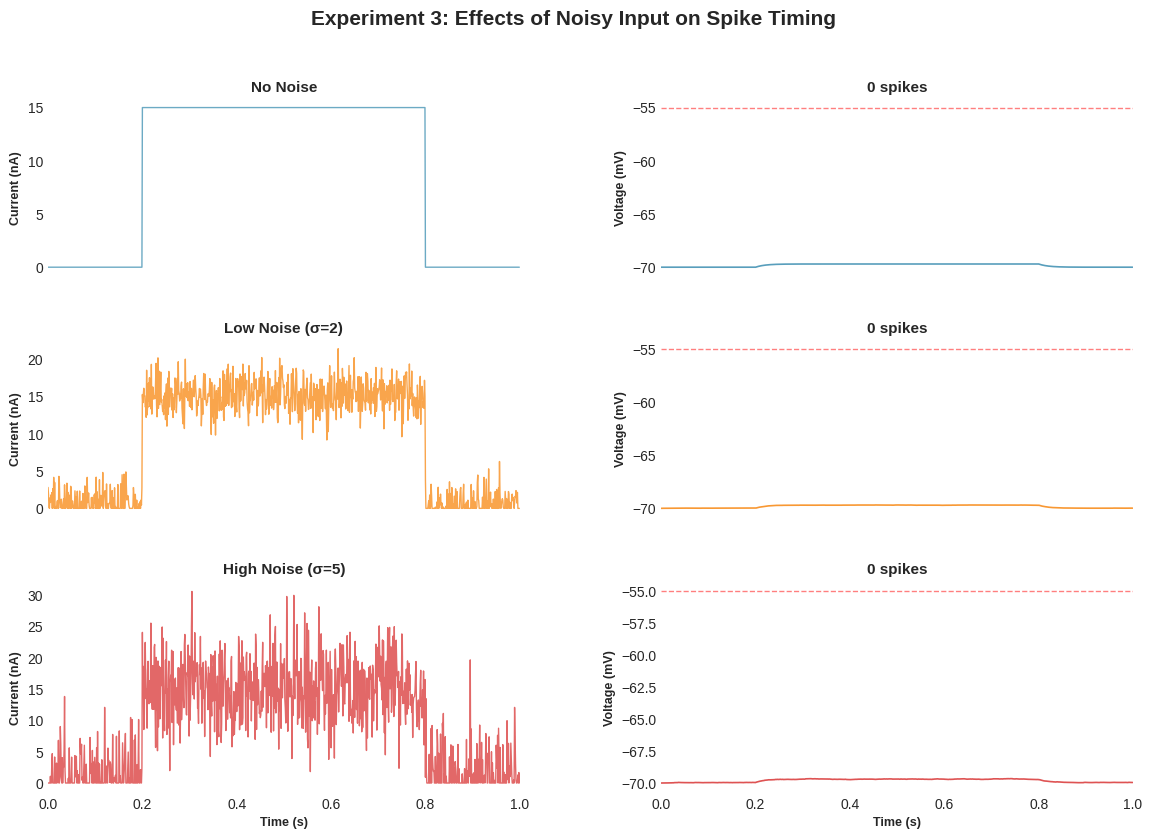


📊 FINDINGS:
   • Clean input → Regular, predictable spikes
   • Noisy input → Irregular timing (more biologically realistic)
   • High noise → Can trigger extra spikes or suppress expected spikes


In [17]:
# Visualize Experiment 3
fig = plt.figure(figsize=(14, 9))
gs = GridSpec(3, 2, height_ratios=[1, 1, 1.2], hspace=0.35, wspace=0.3)

colors_exp3 = ['#2E86AB', '#F77F00', '#D62828']

# Input currents
for i, label in enumerate(noise_labels):
    ax = fig.add_subplot(gs[i, 0])
    ax.plot(time, results_exp3['input'][i], color=colors_exp3[i], linewidth=1, alpha=0.7)
    ax.set_ylabel('Current (nA)', fontsize=9, fontweight='bold')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, T])
    if i < 2:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Time (s)', fontsize=9, fontweight='bold')

# Voltage traces with spike rasters
for i, label in enumerate(noise_labels):
    ax = fig.add_subplot(gs[i, 1])
    ax.plot(time, results_exp3['voltage'][i], color=colors_exp3[i], linewidth=1.2, alpha=0.8)
    ax.axhline(y=V_thresh, linestyle='--', color='red', linewidth=1, alpha=0.5)

    # Mark spikes
    for spike_t in results_exp3['spike_times'][i]:
        ax.axvline(x=spike_t, color='orange', alpha=0.4, linewidth=0.8)

    ax.set_ylabel('Voltage (mV)', fontsize=9, fontweight='bold')
    ax.set_title(f'{len(results_exp3["spike_times"][i])} spikes', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, T])
    if i < 2:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Time (s)', fontsize=9, fontweight='bold')

plt.suptitle('Experiment 3: Effects of Noisy Input on Spike Timing',
             fontsize=15, fontweight='bold')
plt.show()

print('\n📊 FINDINGS:')
print('   • Clean input → Regular, predictable spikes')
print('   • Noisy input → Irregular timing (more biologically realistic)')
print('   • High noise → Can trigger extra spikes or suppress expected spikes')

### Experiment 3 Analysis

**Results Summary:**
- **No noise**: Regular spike intervals (clock-like)
- **Low noise**: Slight timing jitter
- **High noise**: Irregular firing, some extra/missing spikes

**Biological Realism:**

Real neurons face multiple noise sources:
1. **Channel noise**: Stochastic opening/closing of ion channels
2. **Synaptic noise**: Random vesicle release
3. **Network noise**: Background activity from thousands of synapses

Measured CV values in cortex:
- **Regular firing**: CV ≈ 0.2-0.5 (e.g., motor cortex during movement)
- **Irregular firing**: CV ≈ 0.8-1.2 (e.g., spontaneous cortical activity)

**Functional Role of Noise:**
- **Stochastic resonance**: Weak signals detected better with optimal noise
- **Decorrelation**: Prevents pathological synchrony
- **Exploration**: Enables flexible state transitions
- **Information encoding**: Trial-to-trial variability carries information

---
## Final Reflection

### Q1: What does τ represent biologically?

The time constant τ = RC represents:
- **R (resistance)**: How easily ions leak across membrane
  - More channels open → lower R → faster decay
  - Myelination → higher R → slower decay
- **C (capacitance)**: How much charge the membrane can store
  - Larger surface area → higher C → slower changes
  - Dendritic branching increases C

**Variability across neuron types:**
- Fast-spiking interneurons: Low R, low C → small τ (5-10 ms)
- Pyramidal neurons: Medium R, high C → medium τ (15-30 ms)
- Large projection neurons: High R, high C → large τ (40-100 ms)

### Q2: How did encoding strategies preserve information?

**Rate Coding:**
- ✓ Preserved: Relative magnitudes (ordering maintained)
- ✓ Robust: Averaging reduces noise
- ✗ Lost: Exact timing, fast response
- **Trade-off**: Accuracy vs. speed

**Temporal Coding:**
- ✓ Preserved: Rank order (which is largest)
- ✓ Fast: Immediate readout possible
- ✗ Lost: Precise magnitude differences
- **Trade-off**: Speed vs. precision

### Q3: What did layer propagation show?

The network demonstrated:
1. **Convergence**: Multiple inputs integrate at output
2. **Filtering**: Not all spikes propagate through layers
3. **Temporal delays**: Spikes arrive at different times
4. **Summation**: Coincident inputs trigger output spikes

**Similarity to cortical processing:**
- Feedforward inhibition sharpens responses
- Higher layers have more selective receptive fields
- Temporal integration creates feature detectors
- E.g., V1 → V2 → V4 hierarchy for visual features

### Q4: Limitations of LIF model

**What's missing:**

| Feature | Reality | LIF Model |
|---------|---------|----------|
| **Spike shape** | Action potential waveform | Instantaneous reset |
| **Ion channels** | Multiple types (Na, K, Ca) | Single leak |
| **Dendrites** | Active conductances, nonlinear | Point neuron |
| **Adaptation** | Spike-frequency accommodation | None |
| **Synapses** | AMPA, NMDA, GABA dynamics | Instantaneous current |
| **Plasticity** | Learning, homeostasis | Fixed weights |

**When LIF is sufficient:**
- Large-scale network dynamics
- Population coding studies
- Computational principles

**When to use detailed models:**
- Single-cell biophysics
- Dendritic computation
- Drug effects on channels

### Q5: Insights on neural computation

**Key lessons from simulations:**

1. **Parameter sensitivity**: Small changes (threshold, τ) dramatically alter behavior
   - Evolution fine-tunes parameters for specific functions
   - Disease can result from parameter drift

2. **Encoding diversity**: Multiple strategies coexist
   - Brain uses redundancy for robustness
   - Context determines which code dominates

3. **Network effects**: Collective behavior ≠ sum of parts
   - Emergent oscillations, synchrony
   - Feedback amplifies or stabilizes

4. **Information efficiency**: Spikes are metabolically expensive
   - Sparse coding maximizes information/spike
   - Brain balances accuracy vs. energy

5. **Noise as feature**: Variability isn't just error
   - Enables probabilistic computation
   - Prevents pathological states

**Implications for AI:**
- Spiking neural networks (SNNs) for energy-efficient computing
- Temporal credit assignment in learning
- Event-based sensors (DVS cameras)
- Neuromorphic hardware (Intel Loihi, IBM TrueNorth)

---

### Conclusion

This notebook explored fundamental principles of neural computation through simulation:
- LIF neurons capture essential integrate-and-fire dynamics
- Different encoding schemes trade off speed vs. precision
- Networks exhibit emergent properties through interaction
- Parameter choices profoundly affect computational capabilities

Despite its simplicity, the LIF model remains a workhorse of computational neuroscience, providing insights into how biological neurons process information while remaining tractable for large-scale simulations.

**Future directions:**
- Add inhibitory connections
- Implement synaptic plasticity (STDP)
- Explore recurrent network dynamics
- Test on computational tasks (XOR, pattern completion)

---
**End of Notebook**